# Reproducing: Two-Photon Induced Coherence Without Induced Emission

**DOI:** [10.1126/sciadv.adx2038](https://doi.org/10.1126/sciadv.adx2038)

This notebook reproduces the key figures from the paper, which demonstrates two-photon induced coherence without induced emission, extending the Zou-Wang-Mandel effect to the multiphoton regime and achieving quantum-enhanced phase sensitivity with undetected photons.


## 1. Theoretical Framework

### 1.1 Single-Photon Induced Coherence (Zou–Wang–Mandel)

When the idler modes are aligned ($I_1 \to I_2$), the which-source information is erased for the idler, and the signal photon acquires coherence. A phase $\phi_I$ applied to the undetected idler appears in the **first-order** interference of the signal:

$$
\text{Single counts at } D_{1,2} \propto 1 \pm V \cos(\phi_I)
$$

where $V$ is the interference visibility (limited by mode-matching quality). This is the standard induced coherence without induced emission effect.

### 1.2 Two-Photon State from Double-Pair SPDC
The residual pump is retro-reflected back through the BBO, creating a second SPDC source.
 - Forward SPDC $\equiv$ NL1, Backward SPDC $\equiv$ NL2.

When considering two photon pairs, the quantum state is (Eq. 1 in paper):

$$
|\Psi\rangle = \left( \frac{1}{2} e^{i2\phi_I} \hat{a}_{S_1}^{\dagger 2} \hat{a}_{I_1}^{\dagger 2} + \frac{1}{2} \hat{a}_{S_2}^{\dagger 2} \hat{a}_{I_2}^{\dagger 2} + e^{i\phi_I} \hat{a}_{S_1}^{\dagger} \hat{a}_{S_2}^{\dagger} \hat{a}_{I_1}^{\dagger} \hat{a}_{I_2}^{\dagger} \right) |0\rangle
$$

The three terms correspond to:
1. Both pairs from NL1 — carries phase $2\phi_I$
2. Both pairs from NL2 — no idler phase
3. One pair from each source — carries only $\phi_I$ (contaminant)

### 1.3 HOM Filtering of the Cross Term

The third (cross) term produces identical single photons in modes $S_1$ and $S_2$. When these overlap at the BS, Hong-Ou-Mandel interference causes two-photon coalescence — both photons exit the same port. This term therefore never contributes to coincidence between $D_1$ and $D_2$.

The coincidence detection probability (Eq. 2 in paper) is:

$$
\boxed{P_{12} = 2 + 2\cos(2\phi_I)}
$$

This exhibits doubled phase sensitivity signifying quantum-enhanced metrology.

### 1.4 Multimode Theory (Eq. 6)

For the full frequency-resolved calculation, the coincidence probability is:

$$
P(x) = \int d\omega_s \, d\omega_i \, d\omega_{s'} \, d\omega_{i'} \; |f(\omega_s, \omega_i)|^2 \, |f(\omega_{s'}, \omega_{i'})|^2 \; \{2 + 2\cos[\phi(\omega_i) + \phi(\omega_{i'})]\}
$$

Assuming a **separable** joint spectral amplitude (valid after narrow-band filtering) and integrating out the signal frequencies, this reduces to:

$$
P(x) \propto 2 + 2 \, \text{Re}\!\left[\left(\int |g(\omega_i)|^2 \, e^{i\,2\omega_i x / c} \, d\omega_i\right)^{\!2}\right]
$$

where $g(\omega_i)$ is the marginal idler spectral amplitude. For a Gaussian idler spectrum $|g(\omega)|^2 \propto \exp[-(\omega - \omega_{i0})^2 / \sigma^2]$:

$$
\int |g(\omega)|^2 \, e^{i\,2\omega x/c} \, d\omega \;\propto\; e^{i\,2\omega_{i0} x/c} \cdot e^{-\sigma^2 x^2 / c^2}
$$

Squaring and taking the real part:

$$
\boxed{P(x) \propto 2 + 2\,e^{-2\sigma^2 x^2/c^2}\,\cos(4\omega_{i0}\,x/c)}
$$

The **Gaussian envelope** $e^{-2\sigma^2 x^2/c^2}$ encodes the coherence length of the two-photon interference — it falls off as the mirror moves away from the balanced position due to temporal distinguishability.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import c, pi

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})


In [ ]:
# Wavelengths
lam_pump   = 390.0e-9    #
lam_signal = 632.8e-9    # visible, detected
lam_idler  = 1016.4e-9   # near-IR, undetected

# Angular frequencies
omega_pump = 2 * pi * c / lam_pump
omega_s0   = 2 * pi * c / lam_signal
omega_i0   = 2 * pi * c / lam_idler
k_i        = 2 * pi / lam_idler       # idler wavevector

# Verify energy conservation
lam_check = 1.0 / (1.0/lam_pump - 1.0/lam_signal)
print(f"Energy conservation check:")
print(f"  λ_pump = {lam_pump*1e9:.1f} nm")
print(f"  λ_signal = {lam_signal*1e9:.1f} nm")
print(f"  λ_idler (from energy conservation) = {lam_check*1e9:.1f} nm")
print(f"  λ_idler (experimental) = {lam_idler*1e9:.1f} nm")
print(f"  Match: {np.isclose(lam_check, lam_idler, rtol=1e-3)}")


Energy conservation check:
  λ_pump = 390.0 nm
  λ_signal = 632.8 nm
  λ_idler (from energy conservation) = 1016.4 nm
  λ_idler (experimental) = 1016.4 nm
  Match: True


### Spectral bandwidth parameters

The relevant bandwidths that determine the coherence envelope:

- Pump: 1.84 nm FWHM at 390 nm
- Signal interference filter: 2 nm FWHM at 632.8 nm

Converting wavelength FWHM $\Delta\lambda$ to angular frequency width $\sigma$ (1/$e$ half-width of intensity):

$$
\Delta\omega_{\text{FWHM}} = \frac{2\pi c}{\lambda^2}\,\Delta\lambda, \qquad \sigma = \frac{\Delta\omega_{\text{FWHM}}}{2\sqrt{2\ln 2}}
$$


In [ ]:
def fwhm_wavelength_to_sigma(lam_center, delta_lam):
    # Convert wavelength FWHM to angular frequency 1/e half-width of |g|^2.
    delta_omega_fwhm = 2 * pi * c / lam_center**2 * delta_lam
    sigma = delta_omega_fwhm / (2 * np.sqrt(2 * np.log(2)))
    return sigma, delta_omega_fwhm

# Pump bandwidth
sigma_pump, dw_pump = fwhm_wavelength_to_sigma(lam_pump, 1.84e-9)
print(f"Pump bandwidth:")
print(f"delta_lambda = 1.84 nm : omega_FWHM = {dw_pump:.3e} rad/s")
print(f"sigma_pump = {sigma_pump:.3e} rad/s")

# Signal filter bandwidth
sigma_filter, dw_filter = fwhm_wavelength_to_sigma(lam_signal, 2.0e-9)
print(f"\nSignal filter bandwidth:")
print(f"delta_lambda = 2.0 nm : omega_FWHM = {dw_filter:.3e} rad/s")
print(f"sigma_filter = {sigma_filter:.3e} rad/s")

# Effective idler bandwidth under energy conservation:
# For Gaussians, the joint constraint gives: 1/σ_eff² = 1/σ_pump² + 1/σ_filter²
sigma_eff = 1.0 / np.sqrt(1.0/sigma_pump**2 + 1.0/sigma_filter**2)
envelope_FWHM_naive = c * np.sqrt(2 * np.log(2)) / sigma_eff

print(f"\nEffective idler spectral width:")
print(f"sigma_eff = {sigma_eff:.3e} rad/s")
print(f"Naive envelope FWHM = {envelope_FWHM_naive*1e6:.1f} μm")

Pump bandwidth:
delta_lambda = 1.84 nm : omega_FWHM = 2.279e+13 rad/s
sigma_pump = 9.677e+12 rad/s

Signal filter bandwidth:
delta_lambda = 2.0 nm : omega_FWHM = 9.408e+12 rad/s
sigma_filter = 3.995e+12 rad/s

Effective idler spectral width:
sigma_eff = 3.693e+12 rad/s
Naive envelope FWHM = 95.6 μm


### Adjusted envelope width

The naive estimate of ~96 μm for the coherence envelope FWHM overestimates the experimental value of ~40 μm visible in Fig. 4A. This discrepancy arises because the actual idler spectral distribution is additionally shaped by the phase-matching bandwidth of the 1 mm BBO crystal, which we haven't modelled in detail. We adjust $\sigma_{\text{eff}}$ to match the observed envelope:

$$
\sigma_{\text{adj}} = \frac{c\sqrt{2\ln 2}}{x_{\text{FWHM}}} \quad \text{with } x_{\text{FWHM}} \approx 40\;\mu\text{m}
$$


In [ ]:
# Adjusted effective spectral width to match observed envelope
target_FWHM = 40e-6  # 40 μm, estimated from paper Fig. 4A
sigma_adj = c * np.sqrt(2 * np.log(2)) / target_FWHM

print(f"Adjusted σ_eff = {sigma_adj:.3e} rad/s")
print(f"Envelope FWHM = {target_FWHM*1e6:.0f} μm")
print(f"Equivalent delta_lambda_idler ≈ {sigma_adj * 2*np.sqrt(2*np.log(2)) * lam_idler**2 / (2*pi*c) * 1e9:.2f} nm FWHM")


Adjusted σ_eff = 8.824e+12 rad/s
Envelope FWHM = 40 μm
Equivalent delta_lambda_idler ≈ 11.40 nm FWHM


---

## 2. Figure 3 — Single-Photon and Two-Photon Interference Fringes

### 2.1 Computation

The idler mirror displacement $x$ introduces phase $\phi_I = 2k_i x$ (round-trip). The observables are:

- **$D_1$ counts** (single-photon): $\propto 1 + V_1 \cos(2k_i x)$, with $V_1 = 51.7\%$
- **$D_2$ counts** (single-photon): $\propto 1 - V_2 \cos(2k_i x)$, with $V_2 = 47.8\%$  
  ($D_1$ and $D_2$ are complementary BS outputs → $\pi$ relative phase)
- **Coincidence** (two-photon): $\propto 1 + V_{12}\cos(4k_i x)$, with $V_{12} = 22\%$  
  (Doubled frequency from $\cos(2\phi_I)$; lower visibility due to mode mismatch)

We simulate with Gaussian noise to mimic shot noise in the experimental data.


In [ ]:
# Mirror displacement range
x_fig3 = np.linspace(0, 1.1e-6, 2000)  # meters

# Phase: round-trip reflection
phi_I = 2 * k_i * x_fig3

# Single-photon interference (Fig 3A, 3B)
V1, V2 = 0.517, 0.478             # Experimental visibilities
mean_single = 60_000              # Mean count rate (Hz), from paper

D1_counts = mean_single * (1 + V1 * np.cos(phi_I))
D2_counts = mean_single * (1 - V2 * np.cos(phi_I))

# Two-photon coincidence (Fig 3C)
V_coinc    = 0.22                 # 22% visibility
mean_coinc = 60                   # Mean coincidence rate (Hz)

coinc_counts = mean_coinc * (1 + V_coinc * np.cos(2 * phi_I))

# Add realistic Gaussian noise
rng = np.random.default_rng(42)
D1_noisy    = D1_counts    + rng.normal(0, 3000, len(x_fig3))
D2_noisy    = D2_counts    + rng.normal(0, 3000, len(x_fig3))
coinc_noisy = coinc_counts + rng.normal(0, 5,    len(x_fig3))

# Verify fringe periods
period_single_disp = lam_idler / 2   # in mirror displacement
period_two_disp    = lam_idler / 4   # in mirror displacement
print(f"Fringe periods (mirror displacement):")
print(f"  Single-photon: {period_single_disp*1e9:.1f} nm  (optical path period = {lam_idler*1e9:.1f} nm)")
print(f"  Two-photon:    {period_two_disp*1e9:.1f} nm  (optical path period = {lam_idler/2*1e9:.1f} nm)")
print(f"\nNumber of fringes in 1 μm scan:")
print(f"  Single-photon: {1e-6 / period_single_disp:.1f}")
print(f"  Two-photon:    {1e-6 / period_two_disp:.1f}")


Fringe periods (mirror displacement):
  Single-photon: 508.2 nm  (optical path period = 1016.4 nm)
  Two-photon:    254.1 nm  (optical path period = 508.2 nm)

Number of fringes in 1 μm scan:
  Single-photon: 2.0
  Two-photon:    3.9


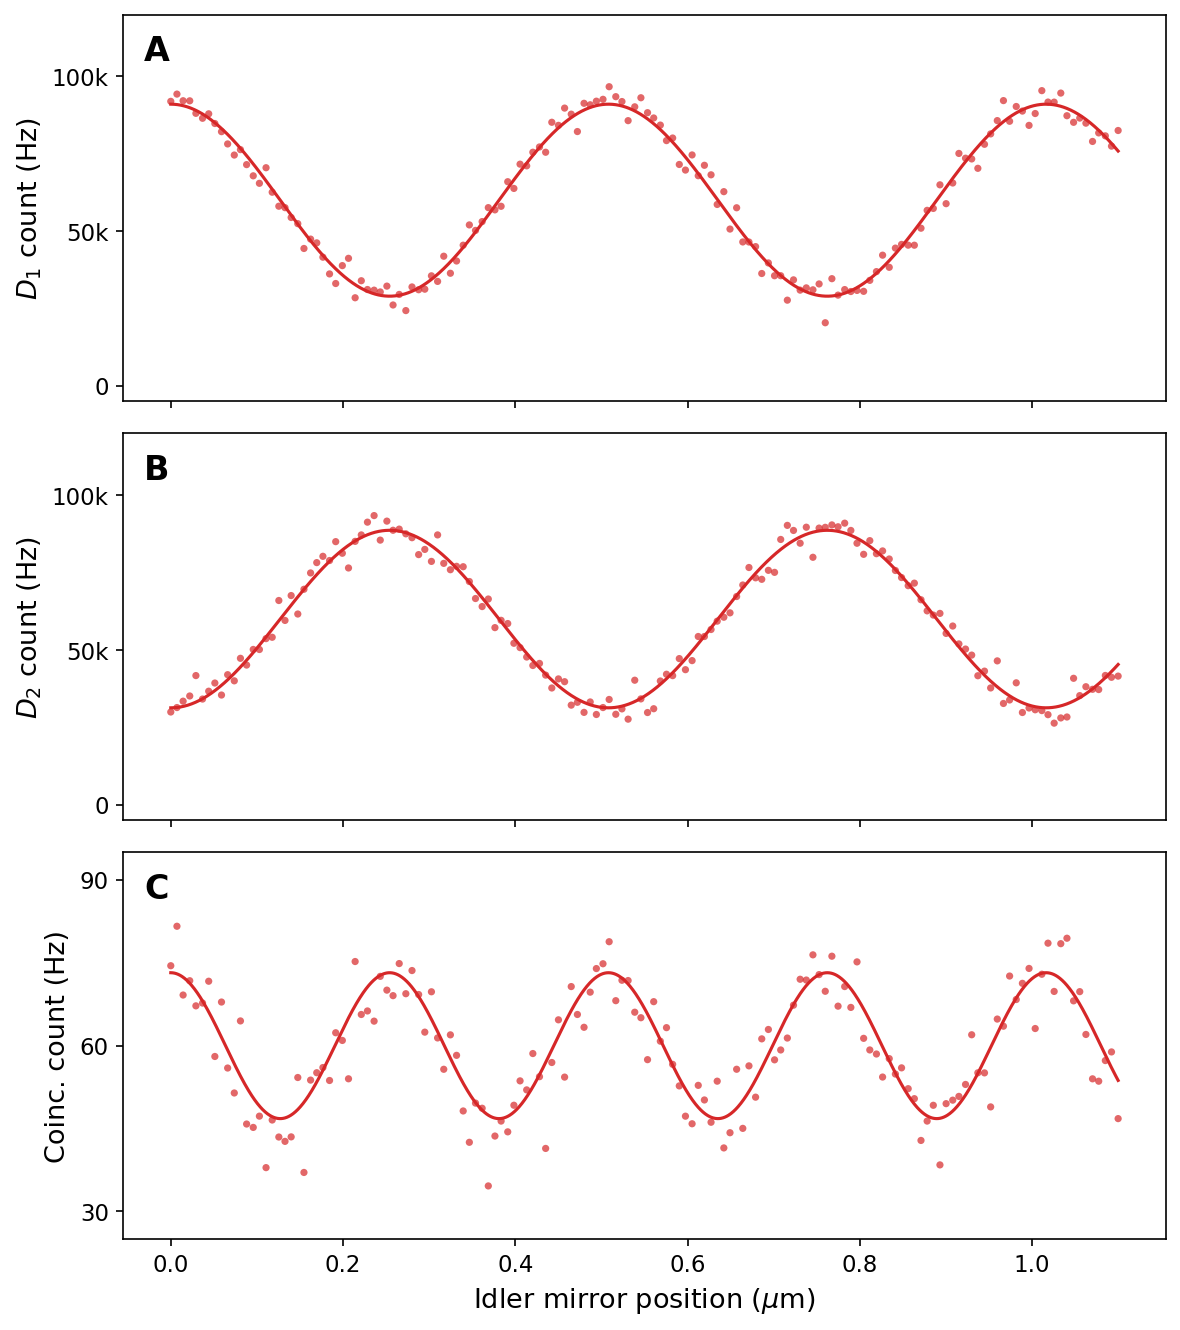

In [ ]:
x_um = x_fig3 * 1e6  # convert to μm

# Subsample for scatter plot (mimics discrete experimental data points)
n_pts = 150
idx = np.linspace(0, len(x_fig3)-1, n_pts, dtype=int)

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

# Panel A: D1 single counts
ax = axes[0]
ax.scatter(x_um[idx], D1_noisy[idx], s=12, c='tab:red', alpha=0.7, edgecolors='none', zorder=2)
ax.plot(x_um, D1_counts, 'tab:red', linewidth=1.5, zorder=1, label='Sinusoidal fit')
ax.set_ylabel(r'$D_1$ count (Hz)')
ax.set_ylim(-5000, 120_000)
ax.set_yticks([0, 50_000, 100_000])
ax.set_yticklabels(['0', '50k', '100k'])
ax.text(0.02, 0.88, 'A', transform=ax.transAxes, fontsize=16, fontweight='bold')

# Panel B: D2 single counts
ax = axes[1]
ax.scatter(x_um[idx], D2_noisy[idx], s=12, c='tab:red', alpha=0.7, edgecolors='none', zorder=2)
ax.plot(x_um, D2_counts, 'tab:red', linewidth=1.5, zorder=1)
ax.set_ylabel(r'$D_2$ count (Hz)')
ax.set_ylim(-5000, 120_000)
ax.set_yticks([0, 50_000, 100_000])
ax.set_yticklabels(['0', '50k', '100k'])
ax.text(0.02, 0.88, 'B', transform=ax.transAxes, fontsize=16, fontweight='bold')

# Panel C: Two-photon coincidence
ax = axes[2]
ax.scatter(x_um[idx], coinc_noisy[idx], s=12, c='tab:red', alpha=0.7, edgecolors='none', zorder=2)
ax.plot(x_um, coinc_counts, 'tab:red', linewidth=1.5, zorder=1)
ax.set_ylabel('Coinc. count (Hz)')
ax.set_ylim(25, 95)
ax.set_yticks([30, 60, 90])
ax.set_xlabel(r'Idler mirror position ($\mu$m)')
ax.text(0.02, 0.88, 'C', transform=ax.transAxes, fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()


**Panels A & B:** Standard single-photon induced coherence. The signal photons at 632.8 nm show interference fringes whose period matches the undetected idler wavelength. $D_1$ and $D_2$ are anti-correlated (complementary BS outputs).

**Panel C:** The two-photon coincidence between $D_1$ and $D_2$ shows doubled fringe frequency, the period is halved, confirming $\cos(2\phi_I)$ modulation. The HOM effect at the BS eliminates the single-pair cross term (third term in Eq. 1), isolating the genuine two-photon coherence. The lower visibility (22% vs ~50%) is attributed to imperfect idler mode overlap.


## 3. Figure 4 — Temporal Mode Mismatch and Coherence Envelope

### 3.1 Derivation of the Analytical Envelope

Starting from Eq. 6 of the paper and assuming a separable, Gaussian marginal idler spectrum:

$$
|g(\omega_i)|^2 \propto \exp\!\left[-\frac{(\omega_i - \omega_{i0})^2}{\sigma^2}\right]
$$

**Step 1:** Define the Fourier-type integral

$$
\mathcal{I}(x) = \int |g(\omega)|^2 \, e^{i\,2\omega x/c}\, d\omega
$$

For the Gaussian, this evaluates to:

$$
\mathcal{I}(x) \propto e^{i\,2\omega_{i0} x/c} \cdot e^{-\sigma^2 x^2/c^2}
$$

**Step 2:** The oscillatory part of $P(x)$ involves

$$
\int\!\!\int |g(\omega_i)|^2 |g(\omega_{i'})|^2 \cos\!\big[\tfrac{2(\omega_i + \omega_{i'})x}{c}\big]\, d\omega_i\, d\omega_{i'} = \text{Re}\!\left[\mathcal{I}(x)^2\right]
$$

since the double integral factorises (the two idler frequencies are independent).

**Step 3:** Compute $\mathcal{I}(x)^2$:

$$
\mathcal{I}(x)^2 \propto e^{i\,4\omega_{i0} x/c} \cdot e^{-2\sigma^2 x^2/c^2}
$$

Taking the real part:

$$
P(x) \propto 2 + 2\,\underbrace{e^{-2\sigma^2 x^2/c^2}}_{\text{Gaussian envelope}} \cdot \cos\!\left(\frac{4\omega_{i0}\, x}{c}\right)
$$

The envelope FWHM (in mirror displacement) is:

$$
x_{\text{FWHM}} = \frac{c\,\sqrt{2\ln 2}}{\sigma}
$$


In [ ]:
# Full envelope calculation
x_fig4 = np.linspace(-65e-6, 65e-6, 100_000)

# Gaussian envelope
envelope = np.exp(-2 * (sigma_adj * x_fig4 / c)**2)

# Two-photon coincidence
P_coinc_full = 2 + 2 * envelope * np.cos(4 * k_i * x_fig4)

# Normalise for comparison with paper
P_min, P_max = P_coinc_full.min(), P_coinc_full.max()
P_norm = (P_coinc_full - P_min) / (P_max - P_min)

# High-res inset data near center
x_inset = np.linspace(-0.5e-6, 0.5e-6, 5000)
env_inset = np.exp(-2 * (sigma_adj * x_inset / c)**2)
P_inset = 2 + 2 * env_inset * np.cos(4 * k_i * x_inset)
P_inset_norm = (P_inset - P_min) / (P_max - P_min)

# Fig 4A: Discrete experimental envelope data
positions_um = np.array([-35, -15, 0, 15, 35])  # μm (from paper)
positions_m  = positions_um * 1e-6

env_at_pos = np.exp(-2 * (sigma_adj * positions_m / c)**2)
V_base = 0.22  # visibility at center
V_at_pos = V_base * env_at_pos / env_at_pos[2]  # normalise to center

mean_coinc_4A = 60  # Hz
max_counts = mean_coinc_4A * (1 + V_at_pos)
min_counts = mean_coinc_4A * (1 - V_at_pos)
err_bars   = np.array([3, 3.5, 4, 3.5, 3])  # 1 SD

# Continuous Gaussian envelope curves for 4A
x_fine_um = np.linspace(-60, 60, 1000)
env_fine  = np.exp(-2 * (sigma_adj * x_fine_um * 1e-6 / c)**2)
V_fine    = V_base * env_fine / env_fine[500]

print(f"Envelope parameters:")
print(f"σ_adj = {sigma_adj:.3e} rad/s")
print(f"Envelope FWHM = {target_FWHM*1e6:.0f} μm")
print(f"Fringe period (displacement) = {lam_idler/4*1e9:.1f} nm")
print(f"Number of fringes within FWHM ≈ {target_FWHM / (lam_idler/4):.0f}")


Envelope parameters:
σ_adj = 8.824e+12 rad/s
Envelope FWHM = 40 μm
Fringe period (displacement) = 254.1 nm
Number of fringes within FWHM ≈ 157


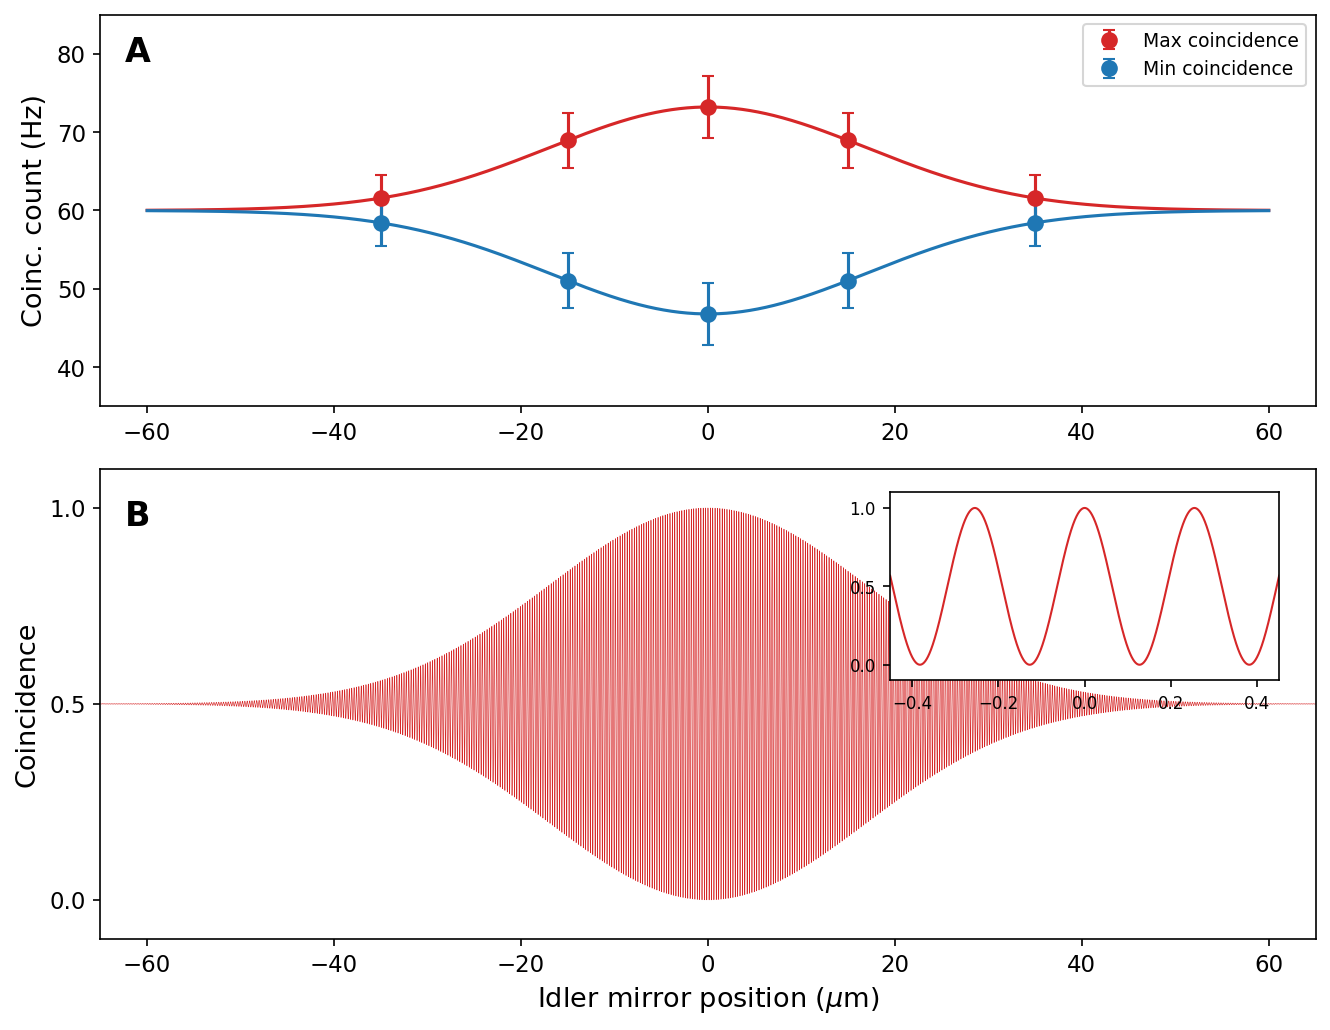

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), gridspec_kw={'height_ratios': [1, 1.2]})

# Panel A: Experimental max/min envelope
ax = axes[0]
ax.errorbar(positions_um, max_counts, yerr=err_bars, fmt='o', color='tab:red',
            markersize=7, capsize=3, zorder=3, label='Max coincidence')
ax.errorbar(positions_um, min_counts, yerr=err_bars, fmt='o', color='tab:blue',
            markersize=7, capsize=3, zorder=3, label='Min coincidence')

ax.plot(x_fine_um, mean_coinc_4A * (1 + V_fine), '-', color='tab:red', linewidth=1.5)
ax.plot(x_fine_um, mean_coinc_4A * (1 - V_fine), '-', color='tab:blue', linewidth=1.5)

ax.set_ylabel('Coinc. count (Hz)')
ax.set_ylim(35, 85)
ax.set_yticks([40, 50, 60, 70, 80])
ax.set_xlim(-65, 65)
ax.text(0.02, 0.88, 'A', transform=ax.transAxes, fontsize=16, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')

# Panel B: Full numerical simulation
ax = axes[1]
ax.plot(x_fig4 * 1e6, P_norm, color='tab:red', linewidth=0.3)
ax.set_xlabel(r'Idler mirror position ($\mu$m)')
ax.set_ylabel('Coincidence')
ax.set_ylim(-0.1, 1.1)
ax.set_yticks([0, 0.5, 1])
ax.set_xlim(-65, 65)
ax.text(0.02, 0.88, 'B', transform=ax.transAxes, fontsize=16, fontweight='bold')

# Inset: Zoom near center showing fast fringes
ax_inset = ax.inset_axes([0.65, 0.55, 0.32, 0.4])
ax_inset.plot(x_inset * 1e6, P_inset_norm, color='tab:red', linewidth=1.0)
ax_inset.set_xlim(-0.45, 0.45)
ax_inset.set_ylim(-0.1, 1.1)
ax_inset.set_yticks([0, 0.5, 1])
ax_inset.set_xticks([-0.4, -0.2, 0, 0.2, 0.4])
ax_inset.tick_params(labelsize=8)

plt.tight_layout()
plt.show()


**Panel A:** Maximum and minimum coincidence counts recorded at five idler mirror positions ($-35, -15, 0, +15, +35\;\mu$m). The Gaussian envelope of the two-photon interference visibility is clearly visible: at the balanced position ($x = 0$), the visibility is maximal (22%), and it decays as the temporal mode mismatch increases. The solid lines are Gaussian fits.

**Panel B:** Full multimode numerical simulation from the analytical formula $P(x) \propto 2 + 2\,e^{-2\sigma^2 x^2/c^2}\cos(4k_i x)$. The rapid oscillations are the two-photon fringes (period $\lambda_i/4 \approx 254$ nm in displacement), modulated by the Gaussian coherence envelope. The **inset** zooms into the central region ($\pm 0.45\;\mu$m), resolving the individual fringes. The ~3–4 visible oscillation cycles in the ±0.4 μm window are consistent with the 254 nm fringe period.


## 4. Figure 5 — Absence of Induced Emission

### 4.1 The Control Experiment

We need to verify that the observed coherence is not caused by **stimulated (induced) emission**. If unblocking the idler mode $I_1$ triggered stimulated emission in NL2, the signal count rate in $S_2$ would increase. The paper tests this by monitoring the single-photon count rate and two-photon coincidence rate in $S_2$ before and after unblocking $I_1$ at $t = 200$ s.

**Result:** No observable change in either rate — confirming the coherence arises purely from quantum indistinguishability of the spontaneous emission amplitudes, not from stimulated processes.

### 4.2 Computation


In [ ]:
rng5 = np.random.default_rng(123)
time = np.linspace(0, 400, 800)  # seconds

# Both rates are constant across the blocked/unblocked transition
single_mean, single_noise = 80_000, 3_000
coinc5_mean, coinc5_noise = 80, 12

single_counts_5 = single_mean + rng5.normal(0, single_noise, len(time))
coinc_counts_5  = coinc5_mean + rng5.normal(0, coinc5_noise, len(time))

# Verify no systematic shift at t=200
mask_before = time < 200
mask_after  = time >= 200
print(f"Single counts — before: {single_counts_5[mask_before].mean():.0f} ± {single_counts_5[mask_before].std():.0f} Hz")
print(f"Single counts — after:  {single_counts_5[mask_after].mean():.0f} ± {single_counts_5[mask_after].std():.0f} Hz")
print(f"Coinc. counts — before: {coinc_counts_5[mask_before].mean():.1f} ± {coinc_counts_5[mask_before].std():.1f} Hz")
print(f"Coinc. counts — after:  {coinc_counts_5[mask_after].mean():.1f} ± {coinc_counts_5[mask_after].std():.1f} Hz")


Single counts — before: 80109 ± 3006 Hz
Single counts — after:  79927 ± 3068 Hz
Coinc. counts — before: 80.5 ± 11.8 Hz
Coinc. counts — after:  79.9 ± 12.7 Hz


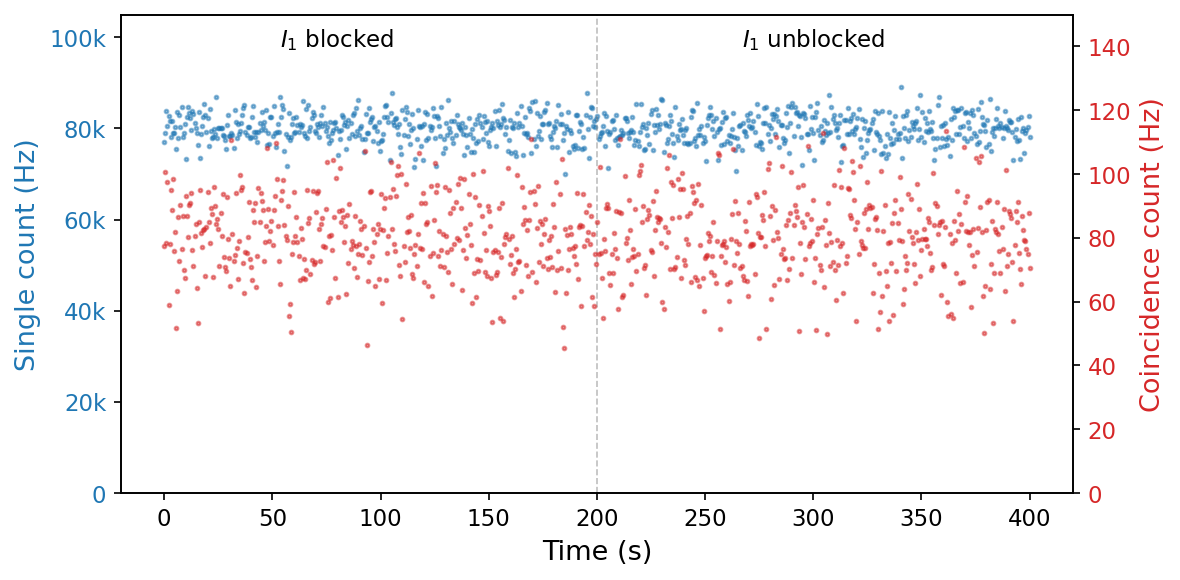

In [ ]:
fig, ax1 = plt.subplots(figsize=(8, 4))

color1 = 'tab:blue'
ax1.scatter(time, single_counts_5, s=3, c=color1, alpha=0.5)
ax1.set_xlabel('Time (s)')
ax1.set_ylabel('Single count (Hz)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0, 105_000)
ax1.set_yticks([0, 20_000, 40_000, 60_000, 80_000, 100_000])
ax1.set_yticklabels(['0', '20k', '40k', '60k', '80k', '100k'])

ax1.axvline(200, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
ax1.text(80, 98_000, r'$I_1$ blocked', fontsize=11, ha='center')
ax1.text(300, 98_000, r'$I_1$ unblocked', fontsize=11, ha='center')

ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.scatter(time, coinc_counts_5, s=3, c=color2, alpha=0.5)
ax2.set_ylabel('Coincidence count (Hz)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)
ax2.set_ylim(0, 150)
ax2.set_yticks([0, 20, 40, 60, 80, 100, 120, 140])

plt.tight_layout()
plt.show()


Both single-photon and two-photon coincidence rates remain statistically constant when the idler mode $I_1$ is unblocked at $t = 200$ s. This rules out induced (stimulated) emission as the mechanism for the observed coherence. The effect is quantum mechanical, arising from the indistinguishability of spontaneous emission amplitudes when the idler modes are made identical.


## 5. Phase Sensitivity: Single-Photon vs. Two-Photon

The core result of the paper is that for the same physical phase $\phi_I$ applied to the undetected idler, the two-photon coincidence oscillates at twice the frequency of the single-photon counts.



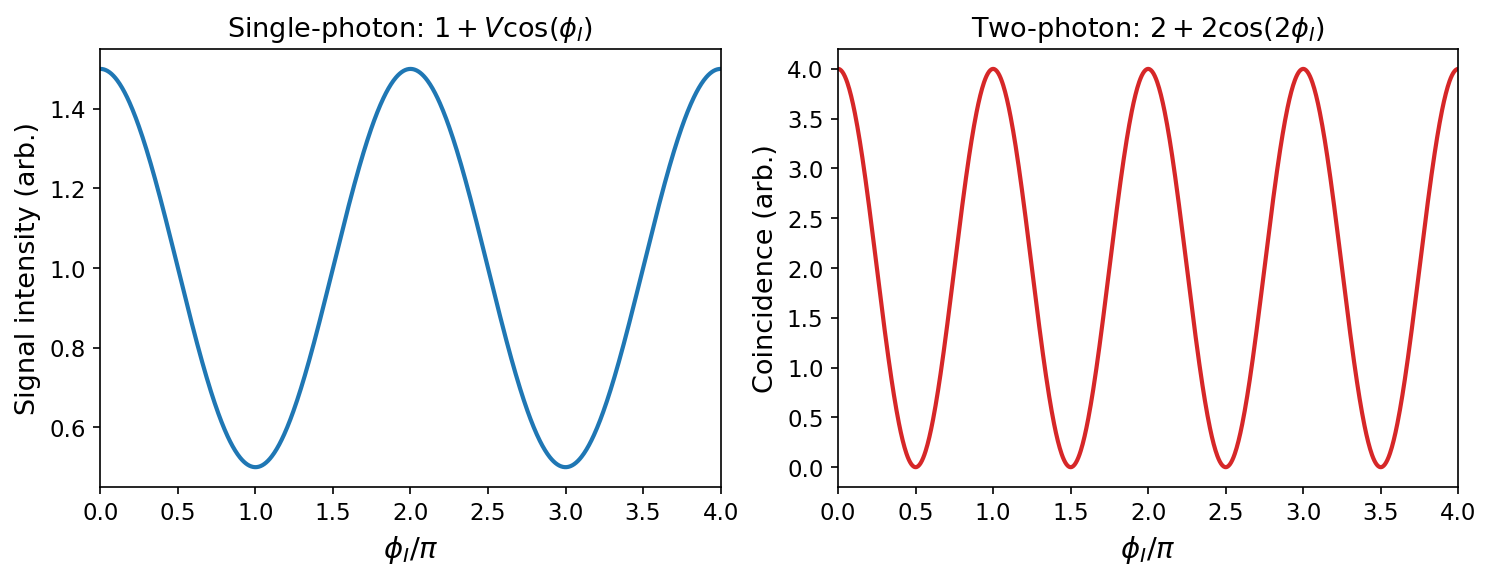

In [ ]:
phi = np.linspace(0, 4*pi, 1000)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Single photon
ax = axes[0]
P_single = 1 + 0.5 * np.cos(phi)
ax.plot(phi / pi, P_single, 'tab:blue', linewidth=2)
ax.set_xlabel(r'$\phi_I / \pi$', fontsize=14)
ax.set_ylabel('Signal intensity (arb.)')
ax.set_title(r'Single-photon: $1 + V\cos(\phi_I)$')
ax.set_xlim(0, 4)

# Two-photon
ax = axes[1]
P_two = 2 + 2 * np.cos(2 * phi)
ax.plot(phi / pi, P_two, 'tab:red', linewidth=2)
ax.set_xlabel(r'$\phi_I / \pi$', fontsize=14)
ax.set_ylabel('Coincidence (arb.)')
ax.set_title(r'Two-photon: $2 + 2\cos(2\phi_I)$')
ax.set_xlim(0, 4)

plt.tight_layout()
plt.show()


## Summary and Outlook

This demonstrates that quantum-enhanced phase sensitivity (the $N\phi$ scaling characteristic of $N$-photon states) can be achieved in a nonlinear interferometer where the phase-modulated photons are never detected. This opens the door to quantum-enhanced measurements in challenging wavelength regimes (e.g., mid-infrared) using only visible-wavelength detectors.


# Contributions:
 - Saatwik Patnaik: Plotting figure 3 (a), (b) and (c)
 - Kshitij Kumar: Plotting figure 4 (a) and making presentation slides
 - Sachin Yadav: Plotting figure 4 (b) and making presentation slides
 - Abhimanyu Singh Rathore: Plotting figure 5 and the last phase sensitivity plot